# 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, log_loss, roc_auc_score, roc_curve
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    train_test_split
)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

# 2. Load Dataset

In [2]:
uploaded = files.upload()

df_train = pd.read_csv("application_train.csv")
df_test = pd.read_csv("application_test.csv")

print(f"Train shape: {df_train.shape}")
print(f"Test shape : {df_test.shape}")

Saving application_test.csv to application_test.csv
Saving application_train.csv to application_train.csv
Train shape: (307511, 122)
Test shape : (48744, 121)


# 3. Exploratory Data Analysis

## 3.1 Head of Data

In [3]:
print('Head of Data - Data Train:')
display(df_train.head())
print('Head of Data - Data Test:')
display(df_test.head())

Head of Data - Data Train:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Head of Data - Data Test:


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 3.2 Dataset Information

In [4]:
print("Dataset Information - Data Train:")
df_train.info(verbose=True)

print("\nDataset Information - Data Test:")
df_test.info(verbose=True)

Dataset Information - Data Train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH  

## 3.3 Statistical Summary

In [5]:
print('Statistical Summary - Data Train:')
display(df_train.describe())

print('Statistical Summary - Data Test:')
display(df_test.describe())

Statistical Summary - Data Train:


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


Statistical Summary - Data Test:


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,48744.000000,48744.000000,4.874400e+04,4.874400e+04,48720.000000,4.874400e+04,48744.000000,48744.000000,48744.000000,48744.000000,...,48744.000000,48744.0,48744.0,48744.0,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000
mean,277796.676350,0.397054,1.784318e+05,5.167404e+05,29426.240209,4.626188e+05,0.021226,-16068.084605,67485.366322,-4967.652716,...,0.001559,0.0,0.0,0.0,0.002108,0.001803,0.002787,0.009299,0.546902,1.983769
std,103169.547296,0.709047,1.015226e+05,3.653970e+05,16016.368315,3.367102e+05,0.014428,4325.900393,144348.507136,3552.612035,...,0.039456,0.0,0.0,0.0,0.046373,0.046132,0.054037,0.110924,0.693305,1.838873
min,100001.000000,0.000000,2.694150e+04,4.500000e+04,2295.000000,4.500000e+04,0.000253,-25195.000000,-17463.000000,-23722.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,188557.750000,0.000000,1.125000e+05,2.606400e+05,17973.000000,2.250000e+05,0.010006,-19637.000000,-2910.000000,-7459.250000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,277549.000000,0.000000,1.575000e+05,4.500000e+05,26199.000000,3.960000e+05,0.018850,-15785.000000,-1293.000000,-4490.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,367555.500000,1.000000,2.250000e+05,6.750000e+05,37390.500000,6.300000e+05,0.028663,-12496.000000,-296.000000,-1901.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000
max,456250.000000,20.000000,4.410000e+06,2.245500e+06,180576.000000,2.245500e+06,0.072508,-7338.000000,365243.000000,0.000000,...,1.000000,0.0,0.0,0.0,2.000000,2.000000,2.000000,6.000000,7.000000,17.000000


## 3.4 Unique Values Each Column

In [6]:
print('Unique Values - Data Train:')
print(df_train.nunique().to_string())

print('\nUnique Values - Data Test:')
print(df_test.nunique().to_string())

Unique Values - Data Train:
SK_ID_CURR                      307511
TARGET                               2
NAME_CONTRACT_TYPE                   2
CODE_GENDER                          3
FLAG_OWN_CAR                         2
FLAG_OWN_REALTY                      2
CNT_CHILDREN                        15
AMT_INCOME_TOTAL                  2548
AMT_CREDIT                        5603
AMT_ANNUITY                      13672
AMT_GOODS_PRICE                   1002
NAME_TYPE_SUITE                      7
NAME_INCOME_TYPE                     8
NAME_EDUCATION_TYPE                  5
NAME_FAMILY_STATUS                   6
NAME_HOUSING_TYPE                    6
REGION_POPULATION_RELATIVE          81
DAYS_BIRTH                       17460
DAYS_EMPLOYED                    12574
DAYS_REGISTRATION                15688
DAYS_ID_PUBLISH                   6168
OWN_CAR_AGE                         62
FLAG_MOBIL                           2
FLAG_EMP_PHONE                       2
FLAG_WORK_PHONE                     

## 3.5 Missing Values Check

In [7]:
print("Missing Values - Data Train:")
print(df_train.isnull().sum().to_string())

print("\nMissing Values - Data Test:")
print(df_test.isnull().sum().to_string())

Missing Values - Data Train:
SK_ID_CURR                           0
TARGET                               0
NAME_CONTRACT_TYPE                   0
CODE_GENDER                          0
FLAG_OWN_CAR                         0
FLAG_OWN_REALTY                      0
CNT_CHILDREN                         0
AMT_INCOME_TOTAL                     0
AMT_CREDIT                           0
AMT_ANNUITY                         12
AMT_GOODS_PRICE                    278
NAME_TYPE_SUITE                   1292
NAME_INCOME_TYPE                     0
NAME_EDUCATION_TYPE                  0
NAME_FAMILY_STATUS                   0
NAME_HOUSING_TYPE                    0
REGION_POPULATION_RELATIVE           0
DAYS_BIRTH                           0
DAYS_EMPLOYED                        0
DAYS_REGISTRATION                    0
DAYS_ID_PUBLISH                      0
OWN_CAR_AGE                     202929
FLAG_MOBIL                           0
FLAG_EMP_PHONE                       0
FLAG_WORK_PHONE                    

## 3.6 Duplicate Check

In [8]:
duplicates_train = df_train[df_train.duplicated()]
duplicates_test  = df_test[df_test.duplicated()]

print(f'Jumlah duplikat di data train : {len(duplicates_train)}')
print(f'Jumlah duplikat di data test  : {len(duplicates_test)}')

Jumlah duplikat di data train : 0
Jumlah duplikat di data test  : 0


## 3.7 Target Distribution (Imbalance Check)

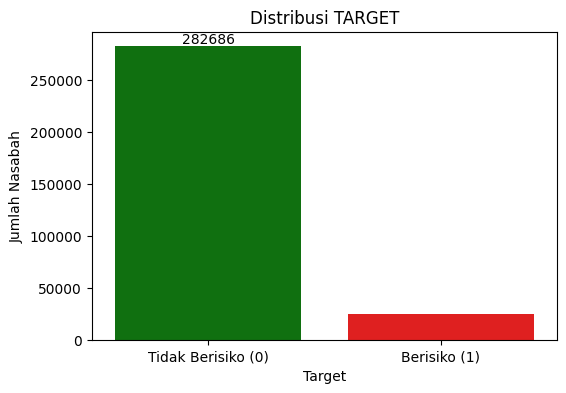

In [9]:
target_count = df_train["TARGET"].value_counts().sort_index()
target_percent = df_train["TARGET"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df_train,
    x="TARGET",
    hue="TARGET",
    palette={0: "green", 1: "red"},
    legend=False
)

ax.bar_label(ax.containers[0])

plt.xticks(
    [0, 1],
    ["Tidak Berisiko (0)", "Berisiko (1)"]
)

plt.xlabel("Target")
plt.ylabel("Jumlah Nasabah")
plt.title("Distribusi TARGET")

plt.show()

## 3.8 Target Distribution by Gender

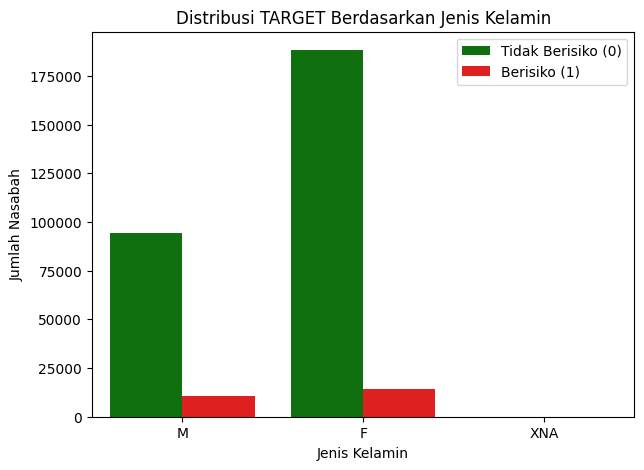

In [10]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_train,
    x="CODE_GENDER",
    hue="TARGET",
    palette=["green", "red"]
)

plt.xlabel("Jenis Kelamin")
plt.ylabel("Jumlah Nasabah")
plt.title("Distribusi TARGET Berdasarkan Jenis Kelamin")

plt.legend(
    labels=["Tidak Berisiko (0)", "Berisiko (1)"]
)

plt.show()

# 3.9 Correlation with TARGET

In [11]:
corr_target = (
    df_train
    .select_dtypes(include="number")
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values(ascending=False)
)

print("Top 10 Positive Correlation with TARGET:")
print(corr_target.head(10).to_frame(name="Correlation"))

print("\nTop 10 Negative Correlation with TARGET:")
print(corr_target.tail(10).to_frame(name="Correlation"))

Top 10 Positive Correlation with TARGET:
                             Correlation
DAYS_BIRTH                      0.078239
REGION_RATING_CLIENT_W_CITY     0.060893
REGION_RATING_CLIENT            0.058899
DAYS_LAST_PHONE_CHANGE          0.055218
DAYS_ID_PUBLISH                 0.051457
REG_CITY_NOT_WORK_CITY          0.050994
FLAG_EMP_PHONE                  0.045982
REG_CITY_NOT_LIVE_CITY          0.044395
FLAG_DOCUMENT_3                 0.044346
DAYS_REGISTRATION               0.041975

Top 10 Negative Correlation with TARGET:
                            Correlation
ELEVATORS_AVG                 -0.034199
REGION_POPULATION_RELATIVE    -0.037227
AMT_GOODS_PRICE               -0.039645
FLOORSMAX_MODE                -0.043226
FLOORSMAX_MEDI                -0.043768
FLOORSMAX_AVG                 -0.044003
DAYS_EMPLOYED                 -0.044932
EXT_SOURCE_1                  -0.155317
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_3                  -0.178919


# 4. Data Preprocesing

## 4.1 Data Cleaning

In [12]:
def clean_data(df, cols_to_drop=None, is_train=True):
    df = df.copy()

    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    days_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
                 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']
    for col in days_cols:
        if col in df.columns:
            df[col] = df[col].abs()

    if is_train:
        missing_pct = df.isnull().mean()
        cols_to_drop = missing_pct[missing_pct > 0.6].index.tolist()
        df = df.drop(columns=cols_to_drop, errors='ignore')
        return df, cols_to_drop

    df = df.drop(columns=cols_to_drop, errors='ignore')
    return df


df_train_clean, cols_high_missing = clean_data(df_train, is_train=True)
df_test_clean = clean_data(df_test, cols_to_drop=cols_high_missing, is_train=False)

print(f"Kolom di-drop (missing >60%) : {len(cols_high_missing)}")
print(f"Shape train : {df_train_clean.shape}")
print(f"Shape test  : {df_test_clean.shape}")

Kolom di-drop (missing >60%) : 17
Shape train : (307511, 106)
Shape test  : (48744, 105)


## 4.2 Feature Engineering

In [13]:
def create_features(df):
    df = df.copy()

    if 'DAYS_BIRTH' in df.columns:
        df['AGE_YEARS'] = df['DAYS_BIRTH'] / 365
    if 'DAYS_EMPLOYED' in df.columns:
        df['EMPLOYED_YEARS'] = df['DAYS_EMPLOYED'] / 365
    if 'DAYS_EMPLOYED' in df.columns and 'DAYS_BIRTH' in df.columns:
        df['EMPLOYMENT_AGE_RATIO'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)

    if 'AMT_CREDIT' in df.columns and 'AMT_INCOME_TOTAL' in df.columns:
        df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    if 'AMT_ANNUITY' in df.columns and 'AMT_INCOME_TOTAL' in df.columns:
        df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    if 'AMT_GOODS_PRICE' in df.columns and 'AMT_CREDIT' in df.columns:
        df['GOODS_CREDIT_RATIO'] = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)
    if 'AMT_CREDIT' in df.columns and 'AMT_ANNUITY' in df.columns:
        df['LOAN_DURATION_MONTHS'] = df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + 1)

    ext_cols = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in df.columns]
    if ext_cols:
        df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)
        df['EXT_SOURCE_STD']  = df[ext_cols].std(axis=1)
        df['EXT_SOURCE_MIN']  = df[ext_cols].min(axis=1)
        df['EXT_SOURCE_MAX']  = df[ext_cols].max(axis=1)

    doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT')]
    if doc_cols:
        df['TOTAL_DOCS_SUBMITTED'] = df[doc_cols].sum(axis=1)

    return df


df_train_fe = create_features(df_train_clean)
df_test_fe  = create_features(df_test_clean)

new_features = [c for c in df_train_fe.columns if c not in df_train_clean.columns]
print(f"Fitur baru : {new_features}")
print(f"Shape train : {df_train_fe.shape}")
print(f"Shape test  : {df_test_fe.shape}")

Fitur baru : ['AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYMENT_AGE_RATIO', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'GOODS_CREDIT_RATIO', 'LOAN_DURATION_MONTHS', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_STD', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'TOTAL_DOCS_SUBMITTED']
Shape train : (307511, 118)
Shape test  : (48744, 117)


## 4.3 Train-Validation Split

In [14]:
X = df_train_fe.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y = df_train_fe['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.copy()
X_val   = X_val.copy()

X_kaggle_test = df_test_fe.drop(columns=['SK_ID_CURR'], errors='ignore')

print(f"X_train : {X_train.shape}  |  X_val : {X_val.shape}")
print(f"\nDistribusi y_train :\n{y_train.value_counts(normalize=True).round(4)}")
print(f"\nDistribusi y_val :\n{y_val.value_counts(normalize=True).round(4)}")

X_train : (246008, 116)  |  X_val : (61503, 116)

Distribusi y_train :
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64

Distribusi y_val :
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


## 4.4 Missing Values Handling

In [15]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols]   = num_imputer.transform(X_val[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols]   = cat_imputer.transform(X_val[cat_cols])

X_kaggle_aligned = X_kaggle_test.reindex(columns=X_train.columns)
X_kaggle_aligned[num_cols] = num_imputer.transform(X_kaggle_aligned[num_cols])
X_kaggle_aligned[cat_cols] = cat_imputer.transform(X_kaggle_aligned[cat_cols])

remaining_missing = X_train.isnull().sum().sum()
print(f"Missing values tersisa di X_train: {remaining_missing}")

Missing values tersisa di X_train: 0


## 4.5 Outlier Handling

In [16]:
cols_to_winsorize = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'LOAN_DURATION_MONTHS',
    'DAYS_EMPLOYED', 'EMPLOYED_YEARS'
]
cols_to_winsorize = [c for c in cols_to_winsorize if c in X_train.columns]

lower_bounds = X_train[cols_to_winsorize].quantile(0.01)
upper_bounds = X_train[cols_to_winsorize].quantile(0.99)

def apply_winsorization(df, lower, upper, cols):
    df = df.copy()
    for col in cols:
        df[col] = df[col].clip(lower=lower[col], upper=upper[col])
    return df

X_train = apply_winsorization(X_train, lower_bounds, upper_bounds, cols_to_winsorize)
X_val   = apply_winsorization(X_val,   lower_bounds, upper_bounds, cols_to_winsorize)
X_kaggle_aligned = apply_winsorization(X_kaggle_aligned, lower_bounds, upper_bounds, cols_to_winsorize)

print(f"Winsorization diterapkan pada {len(cols_to_winsorize)} kolom.")
print(f"Kolom: {cols_to_winsorize}")

Winsorization diterapkan pada 9 kolom.
Kolom: ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'LOAN_DURATION_MONTHS', 'DAYS_EMPLOYED', 'EMPLOYED_YEARS']


## 4.6 Encoding and Scaling

In [17]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
scaler  = StandardScaler()

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_val[cat_cols]   = encoder.transform(X_val[cat_cols])
X_kaggle_aligned[cat_cols] = encoder.transform(X_kaggle_aligned[cat_cols])

X_train_processed = scaler.fit_transform(X_train)
X_val_processed   = scaler.transform(X_val)
X_test_processed  = scaler.transform(X_kaggle_aligned)

feature_names = X_train.columns.tolist()

print(f"X_train_processed : {X_train_processed.shape}")
print(f"X_val_processed   : {X_val_processed.shape}")
print(f"X_test_processed  : {X_test_processed.shape}")
assert X_train_processed.shape[1] == X_val_processed.shape[1] == X_test_processed.shape[1]
print("Semua shape konsisten.")

X_train_processed : (246008, 116)
X_val_processed   : (61503, 116)
X_test_processed  : (48744, 116)
Semua shape konsisten.


# 5. Modelling

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'auc':      'roc_auc',
    'log_loss': make_scorer(log_loss, response_method='predict_proba', greater_is_better=False)
}

## 5.1 Logistic Regression

In [19]:
logreg_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        random_state=42,
        solver="liblinear",
        max_iter=300
    ))
])

logreg_params = {
    "model__C": [0.01, 0.1, 1.0],
    "model__penalty": ["l1", "l2"]
}

logreg_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

logreg_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('model',
                                        LogisticRegression(max_iter=300,
                                                           random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1.0],
                         'model__penalty': ['l1', 'l2']},
             scoring='roc_auc', verbose=1)

## 5.2 XGBoost

In [20]:
neg_pos_ratio = int((y_train == 0).sum() / (y_train == 1).sum())

xgb_pipeline = ImbPipeline([
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="auc",
        verbosity=0,
        scale_pos_weight=neg_pos_ratio
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}

xgb_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('model',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='auc',
                                                      feature_types=None,
                                                      feature_weights=...
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

# 6. Evaluation

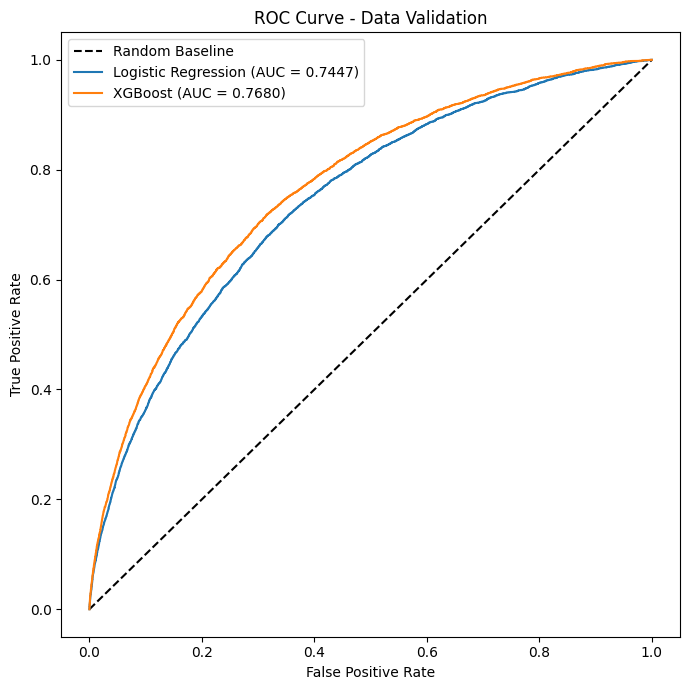

,ROC-AUC,Log Loss
XGBoost,0.7680,0.5358
Logistic Regression,0.7447,0.5836


In [21]:
def evaluate_model(model, X, y):
    y_prob = model.predict_proba(X)[:, 1]

    auc = roc_auc_score(y, y_prob)
    loss = log_loss(y, y_prob)
    fpr, tpr, _ = roc_curve(y, y_prob)

    return auc, loss, fpr, tpr


fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", label="Random Baseline")

results = {}

models = [
    ("Logistic Regression", logreg_search.best_estimator_),
    ("XGBoost", xgb_search.best_estimator_)
]

for name, model in models:

    auc, loss, fpr, tpr = evaluate_model(
        model=model,
        X=X_val_processed,
        y=y_val
    )

    ax.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.4f})"
    )

    results[name] = {
        "ROC-AUC": auc,
        "Log Loss": loss
    }

ax.set_title("ROC Curve - Data Validation")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

plt.tight_layout()
plt.show()

comparison_df = (
    pd.DataFrame(results)
    .T
    .sort_values(by="ROC-AUC", ascending=False)
    .round(4)
)

display(comparison_df)

# 7. Predict on Test Data

## 7.1 Logistic Regression

In [22]:
logreg_proba = logreg_search.best_estimator_.predict_proba(
    X_test_processed
)[:, 1]

submission_logreg = pd.DataFrame({
    "SK_ID_CURR": df_test["SK_ID_CURR"],
    "TARGET": logreg_proba
})

submission_logreg.to_csv(
    "submission_logreg.csv",
    index=False
)

print("Submission - Logistic Regression")
print(f"Jumlah data : {len(submission_logreg):,}")
display(submission_logreg.head())

Submission - Logistic Regression
Jumlah data : 48,744


,SK_ID_CURR,TARGET
0,100001,0.428171
1,100005,0.713928
2,100013,0.218158
3,100028,0.302981
4,100038,0.620985


## 7.2 XGBoost

In [23]:
xgb_proba = xgb_search.best_estimator_.predict_proba(
    X_test_processed
)[:, 1]

submission_xgb = pd.DataFrame({
    "SK_ID_CURR": df_test["SK_ID_CURR"],
    "TARGET": xgb_proba
})

submission_xgb.to_csv(
    "submission_xgb.csv",
    index=False
)

print("Submission - XGBoost")
print(f"Jumlah data : {len(submission_xgb):,}")
display(submission_xgb.head())

Submission - XGBoost
Jumlah data : 48,744


,SK_ID_CURR,TARGET
0,100001,0.262007
1,100005,0.523379
2,100013,0.116791
3,100028,0.317475
4,100038,0.611128


# 8. Feature Importance

## 8.1 Logistic Regression

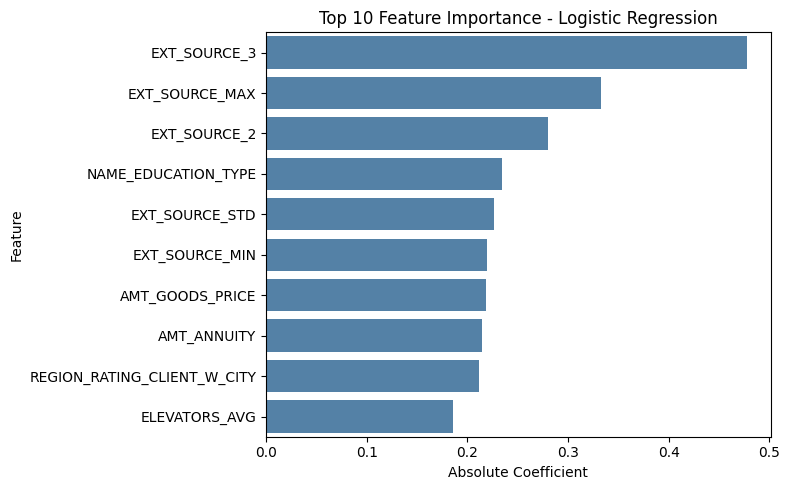

Top 10 Feature Importance - Logistic Regression


,Feature,Importance
40,EXT_SOURCE_3,0.477307
114,EXT_SOURCE_MAX,0.333133
39,EXT_SOURCE_2,0.279949
11,NAME_EDUCATION_TYPE,0.233801
112,EXT_SOURCE_STD,0.226601
113,EXT_SOURCE_MIN,0.219703
8,AMT_GOODS_PRICE,0.218817
7,AMT_ANNUITY,0.214692
28,REGION_RATING_CLIENT_W_CITY,0.211549
44,ELEVATORS_AVG,0.185250


In [24]:
best_logreg = logreg_search.best_estimator_.named_steps["model"]

coef_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": np.abs(best_logreg.coef_[0])
    })
    .sort_values("Importance", ascending=False)
)

top10_coef = coef_df.head(10)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=top10_coef,
    x="Importance",
    y="Feature",
    color="steelblue",
    ax=ax
)

ax.set_title("Top 10 Feature Importance - Logistic Regression")
ax.set_xlabel("Absolute Coefficient")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

print("Top 10 Feature Importance - Logistic Regression")
display(top10_coef)

## 8.2 XGBoost

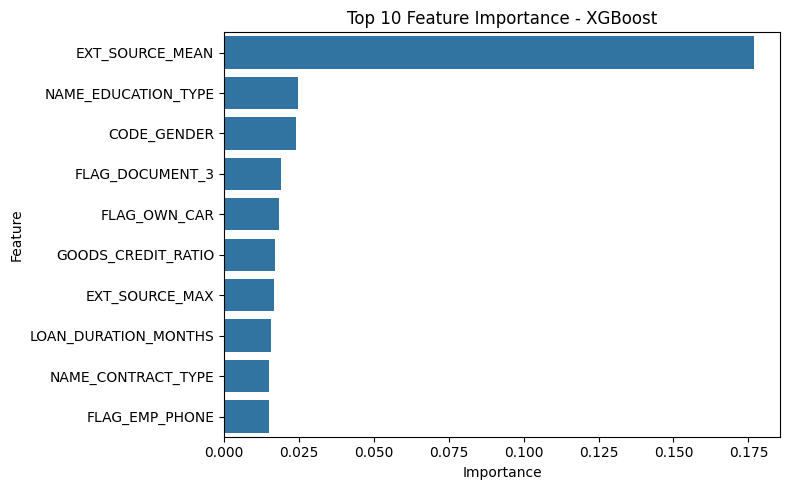

Top 10 Feature Importance - XGBoost


,Feature,Importance
111,EXT_SOURCE_MEAN,0.176709
11,NAME_EDUCATION_TYPE,0.024735
1,CODE_GENDER,0.024041
78,FLAG_DOCUMENT_3,0.019116
2,FLAG_OWN_CAR,0.018423
109,GOODS_CREDIT_RATIO,0.016910
114,EXT_SOURCE_MAX,0.016634
110,LOAN_DURATION_MONTHS,0.015716
0,NAME_CONTRACT_TYPE,0.015029
20,FLAG_EMP_PHONE,0.014939


In [25]:
best_xgb = xgb_search.best_estimator_.named_steps["model"]

xgb_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": best_xgb.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

top10_xgb = xgb_importance.head(10)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=top10_xgb,
    x="Importance",
    y="Feature",
    ax=ax
)

ax.set_title("Top 10 Feature Importance - XGBoost")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

print("Top 10 Feature Importance - XGBoost")
display(top10_xgb)

# 9. Test Set Prediction Analysis

## 9.1 Prediction Summary

In [26]:
threshold = 0.5

pred_lr_binary = (logreg_proba >= threshold).astype(int)
pred_xgb_binary = (xgb_proba >= threshold).astype(int)

n_lr_aman = (pred_lr_binary == 0).sum()
n_lr_berisiko = (pred_lr_binary == 1).sum()

n_xgb_aman = (pred_xgb_binary == 0).sum()
n_xgb_berisiko = (pred_xgb_binary == 1).sum()

total = len(df_test)

summary = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Total Pemohon": [total, total],
    "Prediksi Aman": [
        n_lr_aman,
        n_xgb_aman
    ],
    "Prediksi Berisiko": [
        n_lr_berisiko,
        n_xgb_berisiko
    ],
    "% Aman": [
        f"{n_lr_aman / total:.2%}",
        f"{n_xgb_aman / total:.2%}"
    ],
    "% Berisiko": [
        f"{n_lr_berisiko / total:.2%}",
        f"{n_xgb_berisiko / total:.2%}"
    ]
})

print("Ringkasan Prediksi Test Set (Threshold = 0.5)")
display(summary)

Ringkasan Prediksi Test Set (Threshold = 0.5)


,Model,Total Pemohon,Prediksi Aman,Prediksi Berisiko,% Aman,% Berisiko
0,Logistic Regression,48744,32669,16075,67.02%,32.98%
1,XGBoost,48744,33832,14912,69.41%,30.59%


## 9.2 Predicted Probability Distribution

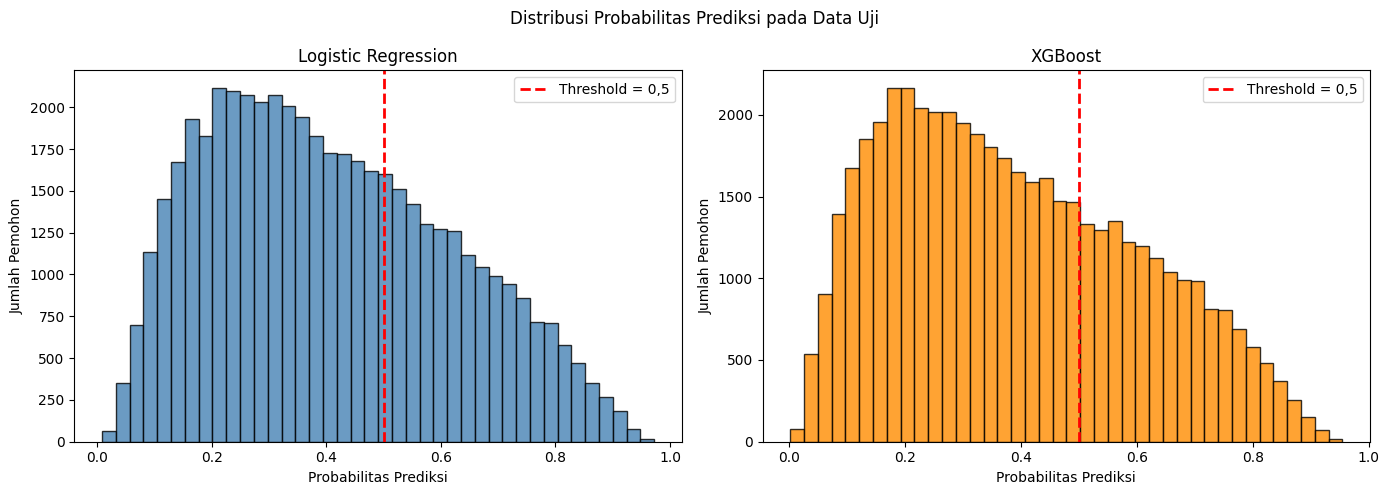

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
axes[0].hist(
    logreg_proba,
    bins=40,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

axes[0].axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Threshold = 0,5"
)

axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Probabilitas Prediksi")
axes[0].set_ylabel("Jumlah Pemohon")
axes[0].legend()

# XGBoost
axes[1].hist(
    xgb_proba,
    bins=40,
    color="darkorange",
    edgecolor="black",
    alpha=0.8
)

axes[1].axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Threshold = 0,5"
)

axes[1].set_title("XGBoost")
axes[1].set_xlabel("Probabilitas Prediksi")
axes[1].set_ylabel("Jumlah Pemohon")
axes[1].legend()

plt.suptitle("Distribusi Probabilitas Prediksi pada Data Uji")

plt.tight_layout()
plt.show()

## 9.3 Comparison of Prediction Results

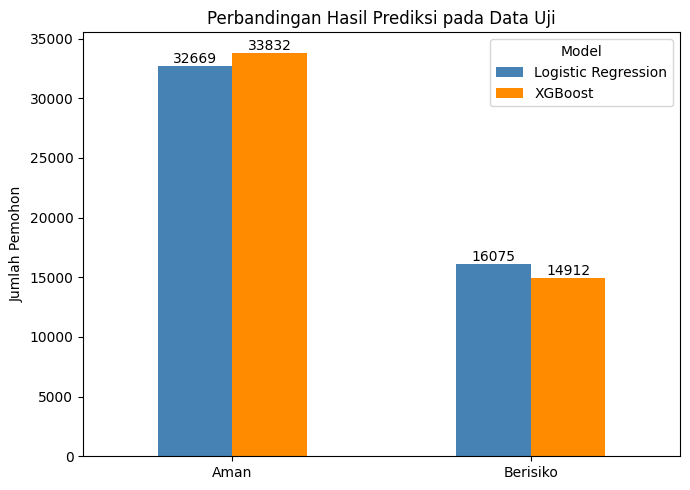

In [28]:
comparison = pd.DataFrame({
    "Status": ["Aman", "Berisiko"],
    "Logistic Regression": [n_lr_aman, n_lr_berisiko],
    "XGBoost": [n_xgb_aman, n_xgb_berisiko]
})

fig, ax = plt.subplots(figsize=(7, 5))

comparison.set_index("Status").plot(
    kind="bar",
    ax=ax,
    color=["steelblue", "darkorange"]
)

ax.set_title("Perbandingan Hasil Prediksi pada Data Uji")
ax.set_xlabel("")
ax.set_ylabel("Jumlah Pemohon")

ax.tick_params(axis="x", rotation=0)

ax.legend(title="Model")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()